<a href="https://colab.research.google.com/github/walnutta/404_project/blob/main/404groupprj_final_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from scipy.sparse import hstack
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import sklearn
import re


In [2]:
from google.colab import drive
import pandas as pd
from sklearn.model_selection import train_test_split

drive.mount("/content/drive")
DRIVE_PATH = "/content/drive/MyDrive/404data/"

df = pd.read_csv(DRIVE_PATH + "train-balanced-sarcasm.csv", low_memory=False)

# sample 310k total, 300k train + 10k test
df_sampled = df.sample(n=810000, random_state=42).reset_index(drop=True)

train_df, test_df = train_test_split(df_sampled, test_size=10000,
    random_state=42, stratify=df_sampled["label"]
)

train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train: {train_df.shape}")
print(f"Test:  {test_df.shape}")
print(f"Train balance: {train_df.label.value_counts().to_dict()}")
print(f"Test balance:  {test_df.label.value_counts().to_dict()}")

Mounted at /content/drive
Train: (800000, 10)
Test:  (10000, 10)
Train balance: {1: 400082, 0: 399918}
Test balance:  {1: 5001, 0: 4999}


In [3]:
reddit_test_df = pd.read_json(
    "https://raw.githubusercontent.com/EducationalTestingService/sarcasm/master/reddit/sarcasm_detection_shared_task_reddit_testing.jsonl",
    lines=True
)

test_df_reddit = reddit_test_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"ETS Reddit test: {test_df.shape}")
print(f"Label balance: {test_df.label.value_counts().to_dict()}")

ETS Reddit test: (10000, 10)
Label balance: {1: 5001, 0: 4999}


In [4]:
train_df.head()

,label,comment,author,subreddit,score,ups,downs,date,created_utc,parent_comment
0,1,What's not to love about corporate welfare?,ENkats,Minneapolis,7,7,0,2016-01,2016-01-27 16:13:40,"This isn't such a tough question, really. It's..."
1,0,"I would *love* for CK2 to push into 1500 or, m...",ElvishisnotTengwar,CrusaderKings,1,1,0,2016-04,2016-04-02 18:36:14,seeing as people made the game work with TES o...
2,0,Money.,commencedownvotes,AskReddit,2,2,0,2014-12,2014-12-27 12:18:17,0 What is your method of attracting girls/maki...
3,1,Why would anyone get a 390 when they can get a...,giotariz,pcmasterrace,4,4,0,2016-03,2016-03-09 07:33:30,*-Insert obligatory comment about how 390 is b...
4,1,You obviously are not thinking of the children...,captmorgan50,todayilearned,17,17,0,2014-02,2014-02-12 17:20:24,They're not being dumb. They know exactly what...


In [5]:
train_df.columns

Index(['label', 'comment', 'author', 'subreddit', 'score', 'ups', 'downs',
       'date', 'created_utc', 'parent_comment'],
      dtype='object')

In [11]:
def count_sarcastic_emojis(text):
  sarcastic_emojis = {"🙄", "😒", "😏", "🤦", "💀", "😐", "🫠", "😑", "👏", "🤷"}
  return sum(1 for char in text if char in sarcastic_emojis)

def clean_text(text):
    text = str(text)
    text = re.sub(r'\s*/s\b', '', text)  # remove /s sarcasm tag
    text = re.sub(r'@USER', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def process_row(row):
  # Kaggle uses comment, ETS uses response
  raw = str(row["comment"]) if "comment" in row.index else str(row["response"])

  reply_depth    = len(re.findall(r"@USER", raw))
  exclaim_count  = raw.count("!")
  question_count = raw.count("?")

  cleaned_response = clean_text(raw)

  # Kaggle uses parent_comment (string), ETS uses context (list)
  if "context" in row.index and isinstance(row["context"], list):
    context_str = clean_text(" ".join([str(c) for c in row["context"]]))
  elif "parent_comment" in row.index and pd.notna(row["parent_comment"]):
    context_str = clean_text(str(row["parent_comment"]))
  else:
    context_str = ""

  full_text = cleaned_response + " [CONTEXT] " + context_str

  # Kaggle label is 0/1, ETS label is SARCASM/NOT_SARCASM
  raw_label = row["label"]
  if isinstance(raw_label, str):
    label = 1 if raw_label == "SARCASM" else 0
  else:
    label = int(raw_label)

  return pd.Series({
    "clean_response": cleaned_response,
    "full_text":      full_text,
    "reply_depth":    reply_depth,
    "exclaim_count":  exclaim_count,
    "question_count": question_count,
    "label":          label
  })

train_clean = train_df.apply(process_row, axis=1)
test_clean = test_df.apply(process_row, axis=1)
test_clean_ets = test_df_reddit.apply(process_row, axis=1)

train_clean.head()


,clean_response,full_text,reply_depth,exclaim_count,question_count,label
0,What's not to love about corporate welfare?,What's not to love about corporate welfare? [C...,0,0,1,1
1,"I would *love* for CK2 to push into 1500 or, m...","I would *love* for CK2 to push into 1500 or, m...",0,0,0,0
2,Money.,Money. [CONTEXT] 0 What is your method of attr...,0,0,0,0
3,Why would anyone get a 390 when they can get a...,Why would anyone get a 390 when they can get a...,0,0,1,1
4,You obviously are not thinking of the children...,You obviously are not thinking of the children...,0,0,0,1


# Logistic Regression

              precision    recall  f1-score   support

 Not Sarcasm       0.69      0.72      0.71      4999
     Sarcasm       0.71      0.68      0.69      5001

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



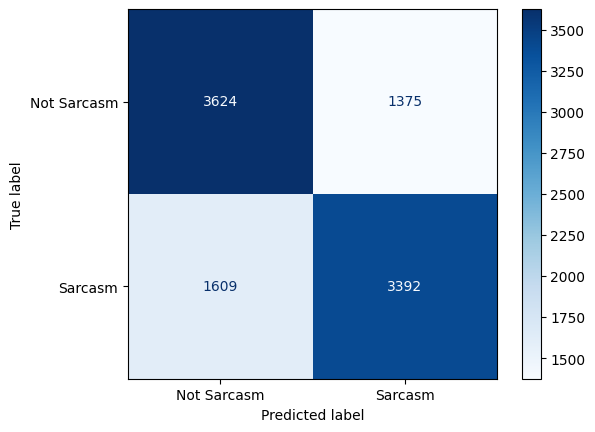

In [12]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50000,
    sublinear_tf=True,
    min_df=2,
    analyzer='word'
)

X_train_tfidf = vectorizer.fit_transform(train_clean["full_text"])
X_test_tfidf  = vectorizer.transform(test_clean["full_text"])

feature_cols = ['reply_depth', 'exclaim_count', 'question_count']

extra_train = train_clean[feature_cols].values
extra_test  = test_clean[feature_cols].values

X_train = hstack([X_train_tfidf, extra_train])
X_test  = hstack([X_test_tfidf,  extra_test])
y_train = train_clean["label"]
y_test  = test_clean["label"]

model = LogisticRegression(max_iter=5000, solver="liblinear", C=1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Not Sarcasm", "Sarcasm"]))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Not Sarcasm", "Sarcasm"]).plot(cmap="Blues")

#### Test on hand-annotated data

LR on ETS (cross-domain):
              precision    recall  f1-score   support

 Not Sarcasm       0.64      0.54      0.58       900
     Sarcasm       0.60      0.69      0.64       900

    accuracy                           0.62      1800
   macro avg       0.62      0.62      0.61      1800
weighted avg       0.62      0.62      0.61      1800



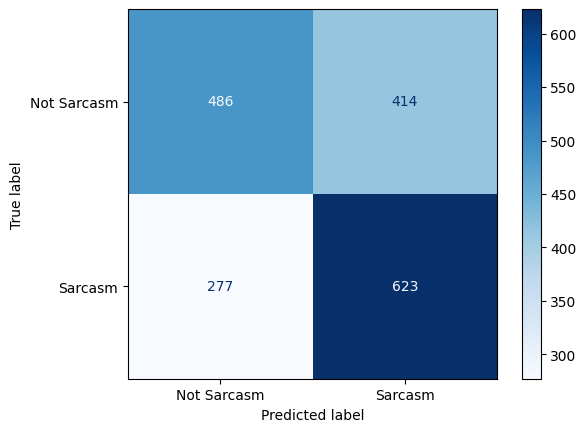

In [14]:
# transform ETS through the already-fitted vectorizer
X_test_tfidf_ets = vectorizer.transform(test_clean_ets["full_text"])

feature_cols = ['reply_depth', 'exclaim_count', 'question_count']
extra_test_ets = test_clean_ets[feature_cols].values

X_test_ets = hstack([X_test_tfidf_ets, extra_test_ets])
y_test_ets = test_clean_ets["label"]

y_pred_ets = model.predict(X_test_ets)

print("LR on ETS (cross-domain):")
print(classification_report(y_test_ets, y_pred_ets, target_names=["Not Sarcasm", "Sarcasm"]))
cm = confusion_matrix(y_test_ets, y_pred_ets)
ConfusionMatrixDisplay(cm, display_labels=["Not Sarcasm", "Sarcasm"]).plot(cmap="Blues")

# RNN

In [15]:
import tensorflow as tf
from tensorflow import keras
from tf_keras.preprocessing.text import Tokenizer
from tf_keras.preprocessing.sequence import pad_sequences
from keras.regularizers import l2
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, GlobalAveragePooling1D

In [16]:
!wget https://nlp.stanford.edu/data/glove.2024.dolma.300d.zip
!unzip glove.2024.dolma.300d.zip

--2026-04-16 00:24:22--  https://nlp.stanford.edu/data/glove.2024.dolma.300d.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.2024.dolma.300d.zip [following]
--2026-04-16 00:24:23--  https://downloads.cs.stanford.edu/nlp/data/glove.2024.dolma.300d.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1673618188 (1.6G) [application/zip]
Saving to: ‘glove.2024.dolma.300d.zip’

glove.2024.dolma.30 100%[===================>]   1.56G  5.01MB/s    in 5m 17s  

2026-04-16 00:29:41 (5.04 MB/s) - ‘glove.2024.dolma.300d.zip’ saved [1673618188/1673618188]

Archive:  glove.2024.dolma.300d.zip
  inf

In [17]:
!ls *.txt

dolma_300_2024_1.2M.100_combined.txt


In [18]:
MAX_VOCAB = 20000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(train_clean["full_text"])

X_train_seq = tokenizer.texts_to_sequences(train_clean["full_text"])
X_test_seq  = tokenizer.texts_to_sequences(test_clean["full_text"])

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

y_train = train_clean["label"].values
y_test  = test_clean["label"].values

print(f"Train shape: {X_train_pad.shape}")
print(f"Test shape:  {X_test_pad.shape}")

glove_embeddings = {}
with open('dolma_300_2024_1.2M.100_combined.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.array(values[1:], dtype='float32')
        glove_embeddings[word] = vector

print(f"Loaded {len(glove_embeddings)} word vectors")

EMBEDDING_DIM = 300
embedding_matrix = np.zeros((MAX_VOCAB, EMBEDDING_DIM))
for word, idx in tokenizer.word_index.items():
    if idx < MAX_VOCAB:
        vector = glove_embeddings.get(word)
        if vector is not None:
            embedding_matrix[idx] = vector

print(f"Embedding matrix shape: {embedding_matrix.shape}")

model = Sequential([
    Embedding(MAX_VOCAB, EMBEDDING_DIM, weights=[embedding_matrix], input_length=MAX_LEN, trainable=True),
    Bidirectional(LSTM(64, return_sequences=True)),
    GlobalAveragePooling1D(),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer='l2'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(X_train_pad, y_train, epochs=40, batch_size=256,
                    validation_data=(X_test_pad, y_test))
model.summary()

Train shape: (800000, 200)
Test shape:  (10000, 200)
Loaded 1200001 word vectors
Embedding matrix shape: (20000, 300)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 69s 20ms/step - accuracy: 0.5587 - loss: 1.3566 - val_accuracy: 0.6207 - val_loss: 1.1739
Epoch 2/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.6231 - loss: 1.0390 - val_accuracy: 0.6338 - val_loss: 0.9167
Epoch 3/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.6456 - loss: 0.8345 - val_accuracy: 0.6600 - val_loss: 0.7569
Epoch 4/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.6648 - loss: 0.7122 - val_accuracy: 0.6703 - val_loss: 0.6684
Epoch 5/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.6761 - loss: 0.6479 - val_accuracy: 0.6810 - val_loss: 0.6245
Epoch 6/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.6829 - loss: 0.6175 - val_accuracy: 0.6890 - val_loss: 0.6036
Epoch 7/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.6886 - loss: 0.6027 - val_accuracy: 0.6906 - val_loss: 0.5949
Epoch 8/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.6934 -

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (256, 200, 300)        │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (256, 200, 128)        │       186,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (256, 128)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (256, 128)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (256, 64)              │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (256, 64)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (256, 1)               │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,585,605 (70.90 MB)

 Trainable params: 6,195,201 (23.63 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12,390,404 (47.27 MB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
              precision    recall  f1-score   support

 Not Sarcasm       0.71      0.75      0.73      4999
     Sarcasm       0.73      0.69      0.71      5001

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.72     10000
weighted avg       0.72      0.72      0.72     10000



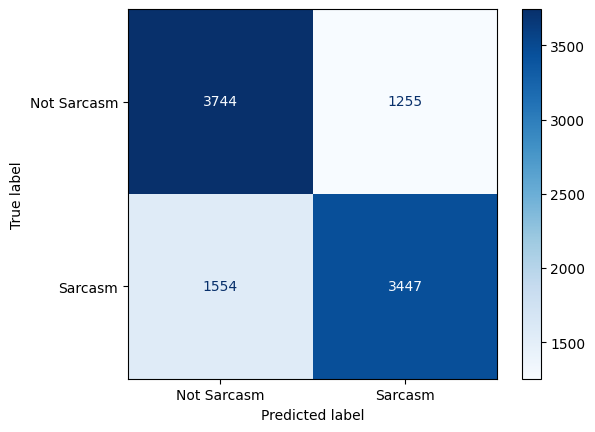

In [19]:
y_pred_prob = model.predict(X_test_pad)
y_pred_rnn = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred_rnn, target_names=["Not Sarcasm", "Sarcasm"]))

cm = confusion_matrix(y_test, y_pred_rnn)
ConfusionMatrixDisplay(cm, display_labels=["Not Sarcasm", "Sarcasm"]).plot(cmap="Blues")

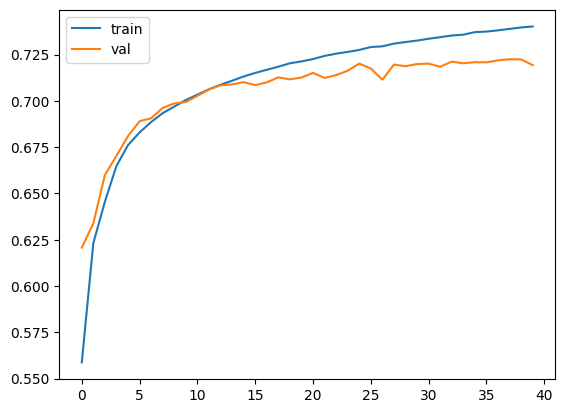

In [20]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()

#### Test on hand-annotated Data

In [ ]:
X_test_seq  = tokenizer.texts_to_sequences(test_clean_ets["full_text"])
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")
y_test  = test_clean_ets["label"].values

print(f"Train shape: {X_train_pad.shape}")
print(f"Test shape:  {X_test_pad.shape}")

model = Sequential([
    Embedding(MAX_VOCAB, EMBEDDING_DIM, weights=[embedding_matrix], input_length=MAX_LEN, trainable=True),
    Bidirectional(LSTM(64, return_sequences=True)),
    GlobalAveragePooling1D(),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer='l2'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(X_train_pad, y_train, epochs=40, batch_size=256,
                    validation_data=(X_test_pad, y_test))
model.summary()

Train shape: (800000, 200)
Test shape:  (1800, 200)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 67s 21ms/step - accuracy: 0.5573 - loss: 1.3453 - val_accuracy: 0.6078 - val_loss: 1.1670
Epoch 2/40
 988/3125 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - accuracy: 0.6104 - loss: 1.1440

## Transformer-Based Model (DistilBERT)


In [ ]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
# Code done from separate notebook and compiled on the final version here
# Constants and Hyperparameters
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128
BATCH_SIZE = 32
EPOCHS = 3
LEARNING_RATE = 2e-5

# Load and Prepare Data
print("Loading and cleaning data...")

# Added low_memory=False to fix the DtypeWarning
df = pd.read_csv("train-balanced-sarcasm.csv", low_memory=False)

# only keep the two columns we care about
if 'comment' in df.columns:
    df = df[['label', 'comment']].copy()
    df = df.rename(columns={'comment': 'full_text'})
else:
    # Fallback just in case
    df = df.iloc[:, 0:2]
    df.columns = ['label', 'full_text']

df['label'] = pd.to_numeric(df['label'], errors='coerce')

# Drop any rows that are missing text or now have a NaN label
df = df.dropna(subset=['label', 'full_text'])

df['full_text'] = df['full_text'].astype(str)
df['label'] = df['label'].astype(int)

print("Sampling 110,000 rows for faster training/testing...")
df_sampled = df.sample(n=110000, random_state=42).reset_index(drop=True)

# Train/Test Split
train_clean, test_clean = train_test_split(df_sampled, test_size=10000, random_state=42)

# Tokenization
print("Initializing Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizing data...")
train_encodings = tokenizer(
    train_clean["full_text"].tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LEN
)

test_encodings = tokenizer(
    test_clean["full_text"].tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LEN
)

# Create PyTorch Dataset Class
class SarcasmDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        # Convert encodings to PyTorch tensors
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

        item['labels'] = torch.tensor(self.labels[idx]).long()

        return item

    def __len__(self):
        return len(self.labels)

print("Building PyTorch datasets...")
train_dataset = SarcasmDataset(train_encodings, train_clean["label"].values)
test_dataset = SarcasmDataset(test_encodings, test_clean["label"].values)

# Model Initialization&Trainer Setup
print("Loading PyTorch DistilBERT model...")
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
).to(device)

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    eval_strategy="epoch",
    logging_dir='./logs',
    logging_steps=100,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

print("Starting training...")
trainer.train()

# Evaluation & Visualization
print("Generating predictions on test set...")
predictions_output = trainer.predict(test_dataset)
preds = predictions_output.predictions

y_pred = np.argmax(preds, axis=1)

print("\nClassification Report:")
print(classification_report(
    test_clean["label"].values,
    y_pred,
    target_names=["Not Sarcasm", "Sarcasm"]
))

print("Generating Confusion Matrix...")
cm = confusion_matrix(test_clean["label"].values, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Sarcasm", "Sarcasm"]
)
disp.plot(cmap="Blues")
plt.title("DistilBERT Sarcasm Detection (PyTorch)")
plt.show()

#### Test on hand-annotated data

This model was replaced by the one above as the final approach, but the initial f1 score and accuracy was around 71% on the Kaggle data

In [ ]:
# Install HuggingFace
!pip install transformers datasets -q
!pip install -q transformers==4.41.2 tensorflow==2.19.0 protobuf==5.29.3
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
from transformers.optimization_tf import create_optimizer

In [ ]:
# Constants for DistilBERT
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 512
BATCH_SIZE = 128
EPOCHS = 3
LEARNING_RATE = 1e-5

In [ ]:
# Loading tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [ ]:
test_encodings = tokenizer(
    test_clean_ets["full_text"].tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LEN
)
# Format the testing data as a TensorFlow dataset
test_dataset = tf.data.Dataset.from_tensor_slices((dict(test_encodings), test_clean["label"].values
)).batch(BATCH_SIZE)

In [ ]:
# Loading model
model = TFAutoModelForSequenceClassification.from_pretrained( MODEL_NAME, num_labels=2)
optimizer, schedule = create_optimizer( init_lr=LEARNING_RATE, num_train_steps=1000, num_warmup_steps=100)

# Full Model Compilation
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [ ]:
train_sub = train_clean.sample(n=100000, random_state=42).reset_index(drop=True)

train_encodings = tokenizer(
    train_sub["full_text"].tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LEN
)

train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    train_sub["label"].values
)).shuffle(1000).batch(BATCH_SIZE)

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS
)

In [ ]:
preds = model.predict(test_dataset).logits
y_pred = np.argmax(preds, axis=1)

print(classification_report(
    test_clean["label"],
    y_pred,
    target_names=["Not Sarcasm", "Sarcasm"]
))

In [ ]:
cm = confusion_matrix(test_clean["label"], y_pred)

ConfusionMatrixDisplay(
    cm,
    display_labels=["Not Sarcasm", "Sarcasm"]
).plot(cmap="Blues")

plt.show()

In [ ]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()

# Analyzing Misclassified Examples

In [ ]:
misclassified_indices = np.where(y_test != y_pred)[0]

misclassified_data = []
for idx in misclassified_indices[:10]: # Displaying first 10 misclassified examples
    text = test_clean['full_text'].iloc[idx]
    true_label = 'Sarcasm' if test_clean['label'].iloc[idx] == 1 else 'Not Sarcasm'
    predicted_label = 'Sarcasm' if y_pred[idx] == 1 else 'Not Sarcasm'
    misclassified_data.append({
        'full_text': text,
        'true_label': true_label,
        'predicted_label': predicted_label
    })

misclassified_df = pd.DataFrame(misclassified_data)
display(misclassified_df)

In [ ]:
# separate false positives and false negatives
false_pos_idx = np.where((y_test == 0) & (y_pred == 1))[0]  # predicted sarcastic, actually not
false_neg_idx = np.where((y_test == 1) & (y_pred == 0))[0]  # predicted not sarcastic, actually is

print(f"False Positives (predicted Sarcasm, actually Not): {len(false_pos_idx)}")
print(f"False Negatives (predicted Not Sarcasm, actually is): {len(false_neg_idx)}")
print()

# length analysis
all_lengths = test_clean['full_text'].str.len()
misclassified_lengths = test_clean['full_text'].iloc[misclassified_indices].str.len()
correct_indices = np.where(y_test == y_pred)[0]
correct_lengths = test_clean['full_text'].iloc[correct_indices].str.len()

print(f"Avg length - misclassified: {misclassified_lengths.mean():.1f} chars")
print(f"Avg length - correct:       {correct_lengths.mean():.1f} chars")
print()

# exclamation and question mark analysis
misc_df = test_clean.iloc[misclassified_indices]
correct_df = test_clean.iloc[correct_indices]

print(f"Avg exclaim_count - misclassified: {misc_df['exclaim_count'].mean():.2f}")
print(f"Avg exclaim_count - correct:       {correct_df['exclaim_count'].mean():.2f}")
print(f"Avg question_count - misclassified: {misc_df['question_count'].mean():.2f}")
print(f"Avg question_count - correct:       {correct_df['question_count'].mean():.2f}")
print()

# context presence
misc_has_context = misc_df['full_text'].str.contains(r'\[SEP\]|\[CONTEXT\]').mean()
correct_has_context = correct_df['full_text'].str.contains(r'\[SEP\]|\[CONTEXT\]').mean()
print(f"Has context - misclassified: {misc_has_context:.2%}")
print(f"Has context - correct:       {correct_has_context:.2%}")

In [ ]:
print("True labels in misclassified data:\n", misclassified_df['true_label'].value_counts())
print("\nPredicted labels in misclassified data:\n", misclassified_df['predicted_label'].value_counts())

In [ ]:
misclassified_df.to_csv('misclassified_entries.csv', index=False)
print("Misclassified entries saved to 'misclassified_entries.csv'")